# Рождения и смерти
Смерть независима от болезни. Поток рождений 10, смертность 0.01.

Row,peak,time_peak,R_T,cases,I_T,vaccinated,population,balance,births,deaths,endemic_S,endemic_I
,Int64,Float64,Int64,Int64,Int64,Int64,Int64,Bool,Int64,Int64,Float64,Float64
1,169,26.3923,151,1902,0,0,1016,true,4242,4226,520.0,18.4615


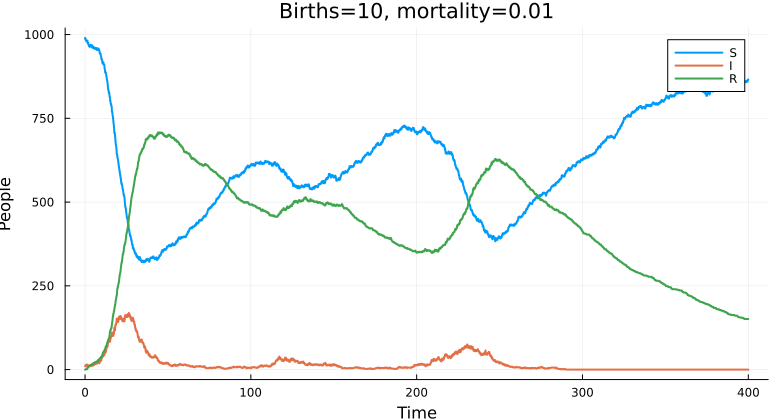

In [1]:
using DrWatson
@quickactivate "ContactEpidemics"
using ContactEpidemics.ContactProcesses
using ContactEpidemics.StudyTools
using DataFrames, CSV, Plots, Statistics


cfg = Settings(mortality=0.01,births=10.0)
m = simulate(config=cfg,T=400.0)
@assert check_balance(m)
save_run(m;label="demography",T=400.0)
data = table(m)
summary = DataFrame([(;run_metrics(m)...,births=last(data.B),
    deaths=last(data.D),endemic_S=1000*(0.25+0.01)/0.5,
    endemic_I=0.01*(1000-520)/(0.25+0.01))])
save_table("demography",summary)
display(summary)
figure = draw_states(m,"demography";title="Births=10, mortality=0.01")
display(plot(figure; size=(780,420)))

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*